In [7]:
# autoencoder_model.ipynb for anomaly-based IDS
# Learns NORMAL traffic patterns
# Flags deviations as attacks

import numpy as np            # for numerical operations
import pandas as pd           # for data handling (dataframe)
import tensorflow as tf       # main ML/DL framework
from tensorflow import keras  # high-level API for building
from sklearn.metrics import(  # evaluation metrics
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report
)

import matplotlib.pyplot as plt  # for plotting results
import time                      # to measure runtime

# check TensorFlow version and confirm libraries loaded
print(f"TensorFlow: {tf.__version__}")
print("Libraries loaded!")

TensorFlow: 2.16.2
Libraries loaded!


In [8]:
# Step 2: Load data
print("Loading data...")
save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/processed/"

X_train = np.load(save_path + "X_train.npy")
X_test  = np.load(save_path + "X_test.npy")  
y_train = pd.read_csv(save_path + "y_train.csv").squeeze()
y_test  = pd.read_csv(save_path + "y_test.csv").squeeze()

# load label classes and feature names
label_classes = pd.read_csv(save_path + "label_classes.csv").squeeze().tolist()
feature_names = pd.read_csv(save_path + "feature_names.csv").squeeze().tolist()

# Autoencoder trains on NORMAL traffic only
# BENIGN = 0 in our label encoding
X_train_normal = X_train[y_train == 0]  # ← changed 'BENIGN' to 0

print(f"X_train total: {X_train.shape}")
print(f"X_train normal only: {X_train_normal.shape}")
print(f"X_test: {X_test.shape}")
print(f"Classes: {label_classes}")
print("Data loaded!")

Loading data...
X_train total: (1979513, 80)
X_train normal only: (1589924, 80)
X_test: (848363, 80)
Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack']
Data loaded!


In [9]:
# Step 3: Build Autoencoder
# Encoder: compress 80 → 32 → 16 (feature reduction)
# Decoder: reconstruct 16 → 32 → 80 (recover original input)
# idea: high reconstruction error = anomaly (attack)

print("Building Autoencoder...")

input_dim = 80  # number of input features

# Encoder
input_layer = keras.Input(shape=(input_dim,))  # input layer (80 features)
encoded = keras.layers.Dense(
    32, activation='relu')(input_layer)        # first hidden layer (80 → 32)
encoded = keras.layers.Dense(
    16, activation='relu')(encoded)            # compressed representation (32 → 16)

# Decoder
decoded = keras.layers.Dense(
    32, activation='relu')(encoded)            # expand back (16 → 32); relu= keep positive numbers,  set nagetive = 0
decoded = keras.layers.Dense(
    input_dim, activation='linear')(decoded)   # reconstruct original size (32 → 80)

# Autoencoder model (input → reconstructed output)
autoencoder = keras.Model(
    input_layer, decoded)

# compile model (optimizer + loss function)
autoencoder.compile(
    optimizer='adam',  # optimization algorithm
    loss='mse')        # reconstruction error (mean squared error); low loss-> noremal(NENIGN), high loss -> anormaly(attack)

# show model structure (layers, params)
autoencoder.summary()

print("Autoencoder built!")


Building Autoencoder...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 80)             │         2,640 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,304 (24.62 KB)

 Trainable params: 6,304 (24.62 KB)

 Non-trainable params: 0 (0.00 B)

Autoencoder built!


In [10]:
# Step 4: Train Autoencoder
# Train on NORMAL(BENIGN) traffic only
# Model learns to reconstruct normal patterns

print("Training Autoencoder...")
print("This takes 10-20 minutes...")

start_time = time.time()  # record start time

# train model: input = output (reconstruction task)
history = autoencoder.fit(
    X_train_normal,X_train_normal, # normal data only (X->X)
    epochs=10,                     # number of training passes
    batch_size=1024,               # examples per batch(faster with large batch)
    validation_split=0.1,          # use 10% of data for validation
    verbose=1                      # show training progress
)

end_time = time.time()        # record start time
ae_train_time = round(end_time - start_time, 2)   # total training time; ae= Autoencoder model

# print training summary
print(f"Training complete!")
print(f"Training time: {ae_train_time} seconds")


Training Autoencoder...
This takes 10-20 minutes...
Epoch 1/10
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 0.4351 - val_loss: 0.3331
Epoch 2/10
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.1542 - val_loss: 0.3068
Epoch 3/10
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.0951 - val_loss: 0.2806
Epoch 4/10
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - loss: 0.1248 - val_loss: 0.2915
Epoch 5/10
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - loss: 0.0703 - val_loss: 0.2815
Epoch 6/10
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - loss: 0.0703 - val_loss: 0.2593
Epoch 7/10
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0844 - val_loss: 0.2530
Epoch 8/10
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0567 - val_loss: 0.2464
Epoch 9/10
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0652 - val_loss: 0.2477
Epoch 10/10
1398/1398 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0522 - val_loss: 0.2390
Training complete!
Training time: 200.19 seconds


In [11]:
# Step 5: Calculate reconstruction error
# Normal traffic = low error
# Attack traffic = high error

print("Calculating reconstruction errors...")

# Use trained autoencoder to reconstruct all test samples
# X_test → input, X_pred → reconstructed output
X_pred = autoencoder.predict(
    X_test, batch_size=1024, verbose=1)

# Mean squared error (MSE) per sample
# Measures reconstruction error: (orignial - reconstructioned)
mse = np.mean(
    np.power(X_test - X_pred, 2), axis=1) # batch size for faster computation, verbose shows progress

print(f"MSE shape: {mse.shape}")    # number of samples
print(f"Mean MSE: {np.mean(mse):.4f}") # average error across all samples
print(f"Max MSE:  {np.max(mse):.4f}")  # highest reconstruction error
print(f"Min MSE:  {np.min(mse):.4f}")  # lowest reconstruction error
print("Reconstruction errors calculated!")

Calculating reconstruction errors...
829/829 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
MSE shape: (848363,)
Mean MSE: 0.1401
Max MSE:  1755.9635
Min MSE:  0.0002
Reconstruction errors calculated!


In [12]:
# Step 6: Find threshold and predict 
# Threashold = 95th percentile of normal errors
# Above threashold= attack
# Below threshold = normal

print("Finding threshold...")

# Reset y_test index to match mse array
y_test_reset = y_test.reset_index(drop=True)

# Get MSE for normal test samples only 
normal_mse = mse[y_test_reset == 0]

# compute 95th percentile -> threshold for anomaly detection
threshold = np.percentile(normal_mse, 95) 
print(f"Threshold: {threshold:.4f}") # show treshold

# predict: above threshold = attack
# 1 = attack (error above threshold), 0 = normal
y_pred_binary = (mse > threshold).astype(int)
y_true_binary = (y_test_reset != 0).astype(int)

# Calculate metrics
acc = accuracy_score(y_true_binary, y_pred_binary) # overall accuracy
p   = precision_score(y_true_binary, y_pred_binary) # correct attach predictions / total predicted attack
r   = recall_score(y_true_binary, y_pred_binary) # detected attacks / total actual attachs
f1  = f1_score(y_true_binary, y_pred_binary) # harmonic mean of predicsion & recall

print(f"\n=== Autoencoder Results ===")
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {p:.4f} ({p*100:.2f}%)")
print(f"Recall:    {r:.4f} ({r*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

Finding threshold...
Threshold: 0.0725

=== Autoencoder Results ===
Accuracy: 0.8553 (85.53%)
Precision: 0.6967 (69.67%)
Recall:    0.4686 (46.86%)
F1-Score:  0.5604 (56.04%)


In [13]:
# Step 5 FIXED(to fix step 6 issues): Recalculate MSE
print("Calculating reconstruction errors...")

X_pred = autoencoder.predict(
    X_test,
    batch_size=1024,
    verbose=1
)

mse = np.mean(
    np.power(X_test - X_pred, 2), axis=1)

print(f"MSE shape: {mse.shape}")
print(f"Mean MSE: {np.mean(mse):.4f}")
print("Reconstruction errors calculated!")

Calculating reconstruction errors...
829/829 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
MSE shape: (848363,)
Mean MSE: 0.1401
Reconstruction errors calculated!


In [21]:
# Debug((to fix step 6 issues)): check what X_test really is
print(f"X_test shape: {X_test.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (1979513, 80)
X_train shape: (1979513, 80)
y_test shape: (848363,)


In [14]:
# Step 2 FIXED((to fix step 6 issues)): Reload data correctly
print("Reloading data...")

save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/processed/"

# Reload correctly
X_train = np.load(save_path + "X_train.npy")
X_test  = np.load(save_path + "X_test.npy")
y_train = pd.read_csv(save_path + "y_train.csv").squeeze()
y_test  = pd.read_csv(save_path + "y_test.csv").squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

# Autoencoder trains on NORMAL only
X_train_normal = X_train[y_train == 0]
print(f"X_train normal: {X_train_normal.shape}")
print("Data reloaded!")

Reloading data...
X_train: (1979513, 80)
X_test:  (848363, 80)
y_train: (1979513,)
y_test:  (848363,)
X_train normal: (1589924, 80)
Data reloaded!


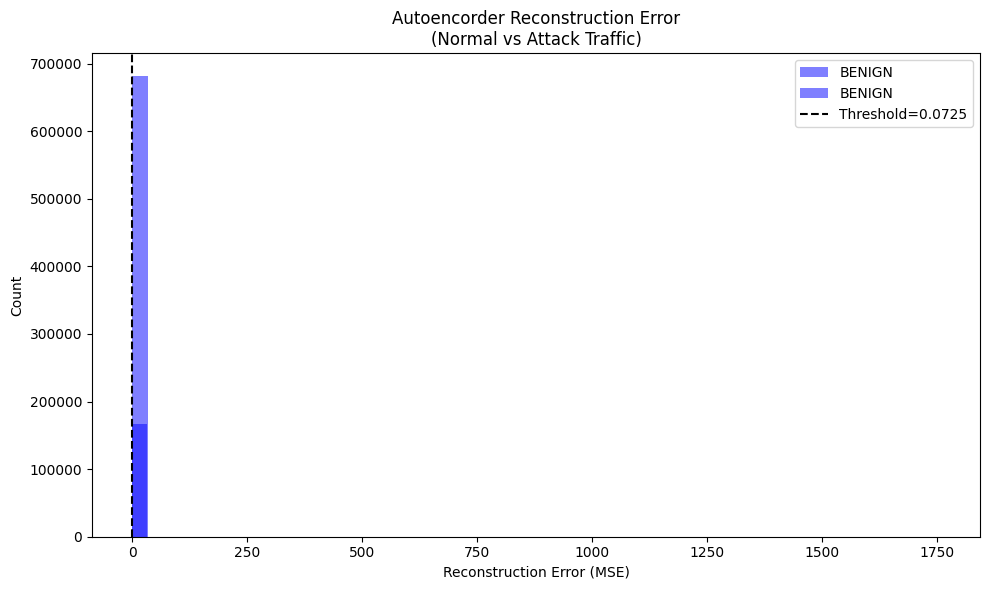

Plot saved!


In [15]:
# Step 7: Plot reconstruciton error
y_test_reset = y_test.reset_index(drop=True)

plt.figure(figsize=(10,6)) # set figure size

# Plot histograms of MSE for normal (BENIGN) samples
plt.hist(
    mse[y_test_reset == 0], # select attach samples
    bins=50, 
    alpha=0.5,
    label='BENIGN', color='blue'
)

# plot histogram of MSE for attack samples
plt.hist(
    mse[y_test_reset != 0],
    bins=50, alpha=0.5,
    label='BENIGN', 
    color='blue'
)

# draw threshold line (95th percentile)
plt.axvline(
           threshold,  # threshold value
           color='black',
           linestyle='--',
           label=f'Threshold={threshold:.4f}') # legend

plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.title('Autoencorder Reconstruction Error\n(Normal vs Attack Traffic)')
plt.legend()
plt.tight_layout()

# Save figure as PNG
plt.savefig(
    save_path + "ae_reconstruction_error.png",
    dpi=150,             # show legend
    bbox_inches='tight'  # adjust layout to avoid clipping
)

plt.show()
print("Plot saved!")
    

In [16]:
# Step 8: Save results
import json

ae_results = {                      # ae = autoencoder
    "model": "Autoencoder",         # model type
    "accuracy": acc,                # overall accuracy
    "precision": p,                 # precision
    "recall": r,                    # recall
    "f1_score": f1,                  # F1-score
    "training_time": ae_train_time, # total training time in seconds
    "threshold": float(threshold),  # anomaly threshold
    "epochs": 10,                   # number of epochs used 
    "batch-size": 1024              # batch size used
}

# Save trained autoencoder model to file
autoencoder.save(save_path + "ae_model.keras")

# Save evaluation results to JSON file
with open(save_path + "ae_results.json", "w") as f:
    json.dump(ae_results, f, indent=4)  # indent for readability
print("Autoencoder saved!")           
print("Results saved!")     

Autoencoder saved!
Results saved!


In [18]:
# Step 9: Copy benchmark repo
import shutil

benchmark = "/Users/miuyanhong/Desktop/TCSS499_Research_Benchmark/results/"

shutil.copy(save_path + "ae_reconstruction_error.png",
            benchmark + "ae_reconstruction_error.png")
shutil.copy(save_path + "ae_results.json",
            benchmark + "ae_results.json")

print("Files copied!")

Files copied!
